#       Proyect Break Machine Learning - The Bridge

<center>
    <img src="./foto-spotify.jpg" alt="ProyectBreakSpotify" width="400" height="300">
</center>

## Entendiendo el problema

En este estudio, mi objetivo es predecir la **popularidad** de nuevas canciones que entren en Spotify a partir de diferentes características de las canciones existentes en el DataSet. Son canciones que van desde el año 1921 hasta el 2020.

He elegido el conjunto de datos *"**Spotify**"* porque:
Contiene información relevante como: año de lanzamiento, valencia, duración, bailabilidad, si es acoústica o no y popularidad entre otras variables.

Incluye variables numéricas y categóricas, lo que permite aplicar técnicas de preprocesamiento como PCA (no supervisado) y modelos de regresión (supervisado).

La popularidad es una variable continua, lo que nos lleva a un problema de regresión en lugar de clasificación.
Es útil en la vida real: es un problema de negocio frecuente en la industria de la música.
 

DATASET: https://data.world/babarory/spotify-dataset-1921-2020/workspace/file?filename=data.csv

## EDA

In [1]:
# Importaciones y DataSet
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error, r2_score, silhouette_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("../data_sample/spotify_sample.csv")

### 1. Revisión General del Dataset
    + Dimensiones del dataset (filas y columnas) ✅
    + Tipos de datos en cada columna ✅
    + Valores nulos y duplicados ✅

In [2]:
# Información general
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17065 entries, 0 to 17064
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   valence           17065 non-null  float64
 1   year              17065 non-null  int64  
 2   acousticness      17065 non-null  float64
 3   artists           17065 non-null  object 
 4   danceability      17065 non-null  float64
 5   duration_ms       17065 non-null  int64  
 6   energy            17065 non-null  float64
 7   explicit          17065 non-null  int64  
 8   id                17065 non-null  object 
 9   instrumentalness  17065 non-null  float64
 10  key               17065 non-null  int64  
 11  liveness          17065 non-null  float64
 12  loudness          17065 non-null  float64
 13  mode              17065 non-null  int64  
 14  name              17065 non-null  object 
 15  popularity        17065 non-null  int64  
 16  release_date      17065 non-null  object

In [3]:
df.head()

,valence,year,acousticness,artists,danceability,duration_ms,energy,explicit,id,instrumentalness,key,liveness,loudness,mode,name,popularity,release_date,speechiness,tempo
0,0.910,1977,0.500,['Idris Muhammad'],0.894,273067,0.5210,0,0KdzyvsBqX1HV3uLxGm2JV,0.772,4,0.068,-7.048,1,Camby Bolongo,34,1977,0.0847,126.805
1,0.583,1976,0.930,['Stan Getz'],0.585,182200,0.2720,0,1f4eO5waC6glPLXUhYKLm2,0.115,11,0.128,-16.693,0,Just One of Those Things,26,1976,0.0802,90.104
2,0.647,1994,0.157,"['Warren G', 'The Twinz']",0.878,179933,0.5200,1,1X07ZfF5KQt8dyJ5kAkVAQ,0.000,7,0.173,-12.609,1,Recognize,38,1994-06-07,0.4030,90.744
3,0.196,1957,0.937,['Red Garland Quintet'],0.463,925947,0.2870,0,5wmMDeM4qvLfwqLa2cvoks,0.837,0,0.112,-11.758,0,Soul Junction,13,1957,0.0363,186.764
4,0.422,1921,0.995,['Ignacio Corsini'],0.648,154240,0.0995,0,0SK1upzAP6NvIgF0uGh6z2,0.846,11,0.112,-22.429,1,Flor Marchita - Remasterizado,0,1921-03-20,0.1050,71.978


**Descripción de las variables:**
* **valence:** Mide lo positivo o feliz que suena una canción (0 = triste, 1 = feliz).

* **year:** Año en el que se lanzó la canción.
* **acousticness:** Probabilidad de que una canción sea acústica (0 = no acústica, 1 = completamente acústica).
* **artists:** Lista con los nombres de los artistas que interpretan la canción.
* **danceability:** Mide lo bailable de una canción (0 = no bailable, 1 = muy bailable).
* **duration_ms:** Duración de la canción en milisegundos.
* **energy:** Nivel de intensidad y actividad de una canción (0 = baja energía, 1 = alta energía).
* **explicit:** Indica si una canción tiene contenido explícito (0 = no, 1 = sí).
* **id:** Identificador único de la canción en Spotify.
* **instrumentalness:** Probabilidad de que una canción sea instrumental (valores altos indican menos voces).
* **key:** La tonalidad de la canción en valores numéricos (de 0 a 11, donde cada número representa una nota musical).
* **liveness:** Probabilidad de que la canción haya sido grabada en vivo (valores altos indican una presentación en vivo).
* **loudness:** Volumen general de la canción en decibelios (dB).
* **mode:** Tipo de escala musical utilizada (0 = menor, 1 = mayor).
* **name:** Nombre de la canción.
* **popularity:** Popularidad de la canción en una escala de 0 a 100 (según Spotify).
* **release_date:** Fecha exacta de lanzamiento de la canción.
* **speechiness:** Mide la presencia de palabras habladas en la canción (valores altos indican más habla).
* **tempo:** Velocidad o ritmo de la canción en beats per minute (BPM).


In [4]:
# Visualizo la variable artists porque puede tener nombres en otros idiomas
df["artists"].value_counts()

artists
['Эрих Мария Ремарк']          128
['Эрнест Хемингуэй']           122
['Francisco Canaro']            85
['The Rolling Stones']          63
['Ignacio Corsini']             59
                              ... 
['The Unlikely Candidates']      1
["Vaquero's Musical"]            1
['Lil Wayne', 'Cory Gunz']       1
['Faith Evans']                  1
['Guy Mitchell']                 1
Name: count, Length: 7941, dtype: int64

In [5]:
# También la variable name para comprobar
df["name"].value_counts()

name
White Christmas            7
Believe                    7
Overture                   7
Jingle Bells               6
Smoke Gets In Your Eyes    6
                          ..
Llorar, Llorar             1
Just An Hour Of Love       1
Return To Heaven           1
Back to the Hotel          1
Anticipation               1
Name: count, Length: 16232, dtype: int64

In [6]:
# Decido traducir los nombres esos dos nombres - pero NO consigo que los traduzca

#from deep_translator import GoogleTranslator
# Valores originales y su traducción manual
#traduccion = {
#   "Эрнест Хемингуэй": "Ernest Hemingway",  
#    "Эрих Мария Ремарк": "Erich Maria Remarque"   
# Reemplazo los valores traducidos en la columna "artists"
#df["artists"] = df["artists"].replace(traduccion)
#print(df[["artists"]].head())


### 2. Preprocesamiento y Limpieza
    + Manejo de valores nulos o erróneos ✅
    + Eliminación de duplicados ✅
    + Eliminar columnas que no son necesarias ✅

In [7]:
# Manejo de valores nulos
print(df.isnull().sum())

valence             0
year                0
acousticness        0
artists             0
danceability        0
duration_ms         0
energy              0
explicit            0
id                  0
instrumentalness    0
key                 0
liveness            0
loudness            0
mode                0
name                0
popularity          0
release_date        0
speechiness         0
tempo               0
dtype: int64


In [8]:
df["year"].unique()[:10]  # Muestra los primeros 10 valores únicos


array([1977, 1976, 1994, 1957, 1921, 2017, 1972, 1951, 1966, 1985])

Es curioso porque en el .info() no me sale que haya nigún nulo pero aquí sí. Debemos tratarlos.

In [9]:
# Tratamiento de la variable year con la moda, aunque es numérica, pero tiene sentido
moda = df["year"].mode()[0] 
df["year"].fillna(moda, inplace=True)

In [10]:
# Ya no hay nulos en la variable year
print(df["year"].isnull().sum())

0


In [11]:
# Tambien con release_date 
moda = df["release_date"].mode()[0] 
df["release_date"].fillna(moda, inplace=True)

In [12]:
print(df["year"].isnull().sum())

0


In [13]:
# Vemos si tenemos duplicados
df.duplicated().sum() # No tenemos.

np.int64(0)

### 3. Análisis Estadístico y Distribuciones
    + Descripción general de las variables numéricas y categóricas ✅
    + Distribución de cada variable numérica (histogramas, boxplots) ✅
    + Outliers (valores atípicos)✅

In [14]:
# Resumen de los valores numéricos
df.describe()

,valence,year,acousticness,danceability,duration_ms,energy,explicit,instrumentalness,key,liveness,loudness,mode,popularity,speechiness,tempo
count,17065.000000,17065.000000,17065.000000,17065.000000,1.706500e+04,17065.000000,17065.000000,17065.000000,17065.000000,17065.000000,17065.000000,17065.000000,17065.000000,17065.000000,17065.000000
mean,0.526204,1976.786288,0.504404,0.537480,2.299477e+05,0.479229,0.087665,0.167635,5.241781,0.206215,-11.489101,0.705713,31.434515,0.101123,117.417752
std,0.262543,26.027997,0.376849,0.175629,1.248398e+05,0.268537,0.282815,0.313963,3.512806,0.175916,5.733850,0.455735,21.904987,0.168333,30.961113
min,0.000000,1921.000000,0.000000,0.000000,5.108000e+03,0.000000,0.000000,0.000000,0.000000,0.000000,-60.000000,0.000000,0.000000,0.000000,0.000000
25%,0.316000,1956.000000,0.099400,0.417000,1.691950e+05,0.251000,0.000000,0.000000,2.000000,0.098600,-14.585000,0.000000,11.000000,0.034900,93.975000
50%,0.537000,1977.000000,0.526000,0.550000,2.070470e+05,0.468000,0.000000,0.000206,5.000000,0.136000,-10.617000,1.000000,33.000000,0.045300,115.424000
75%,0.743000,1999.000000,0.898000,0.667000,2.616270e+05,0.701000,0.000000,0.102000,8.000000,0.262000,-7.206000,1.000000,48.000000,0.076200,136.266000
max,0.993000,2020.000000,0.996000,0.975000,3.551152e+06,1.000000,1.000000,1.000000,11.000000,0.995000,1.342000,1.000000,95.000000,0.969000,220.099000


In [15]:
categoricas = df.select_dtypes(include=["object"]).columns.drop("release_date")
numericas = df.select_dtypes(include=["float64", "int64"]).columns.drop("popularity")
target = "popularity"

In [16]:
# Establezco la paleta de colores que voy a usar en todos mis gráficos
palette_color = "viridis"
sns.set_palette(palette_color)

<Figure size 1500x1000 with 0 Axes>

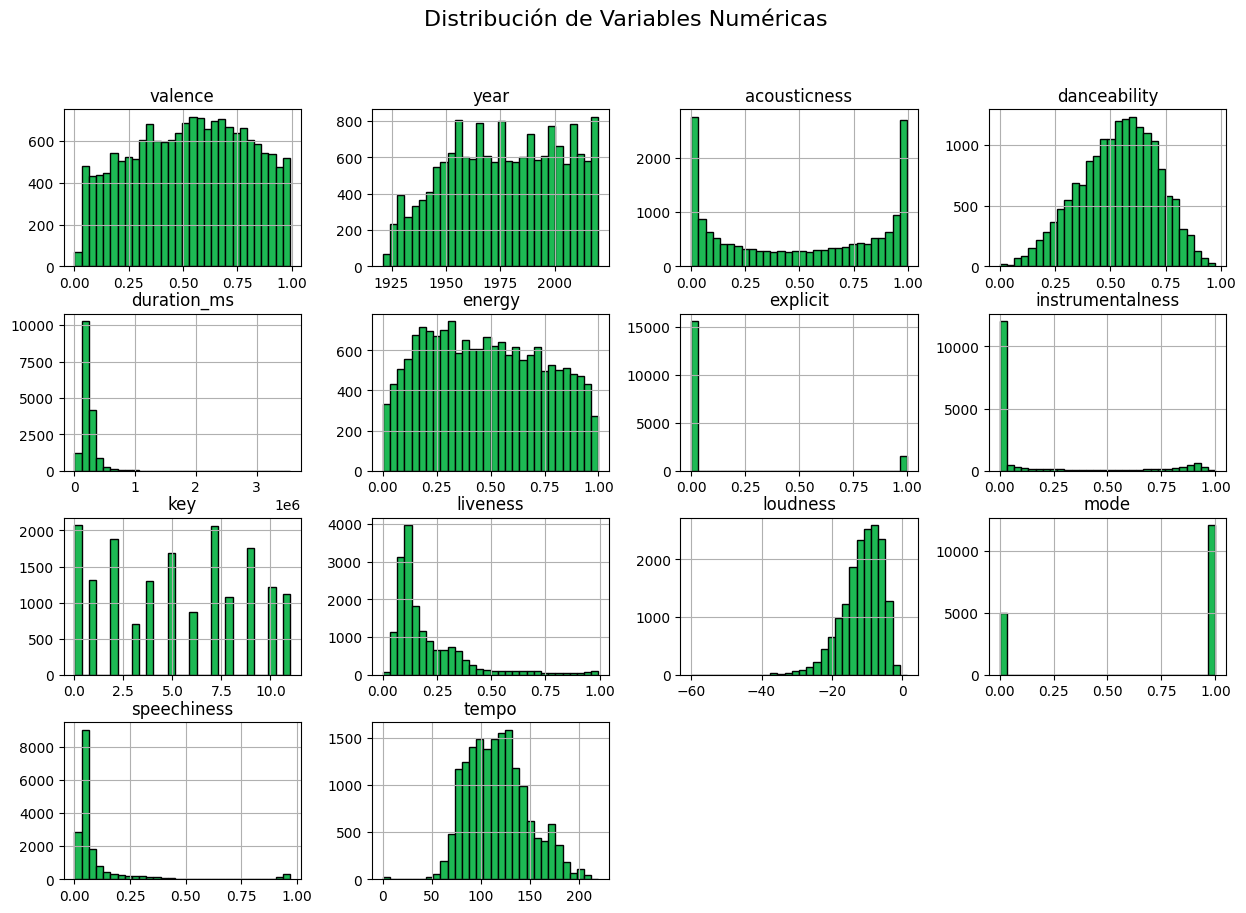

In [17]:
# Distribuciones de variables numéricas con un histplot
plt.figure(figsize=(15, 10))
df[numericas].hist(bins=30, figsize=(15, 10), color="#1DB954", edgecolor="black")
plt.suptitle("Distribución de Variables Numéricas", fontsize=16)
plt.show()

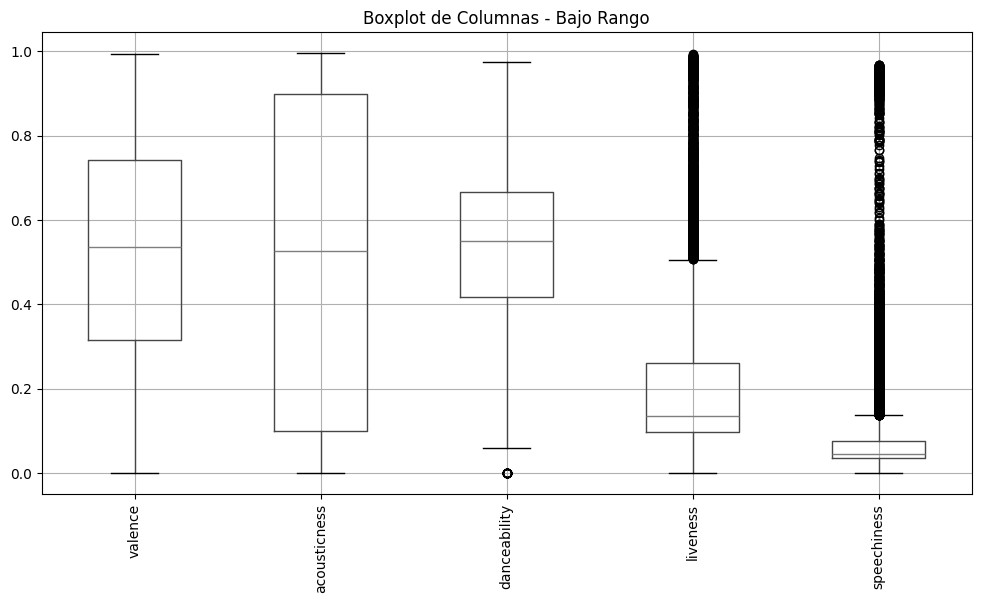

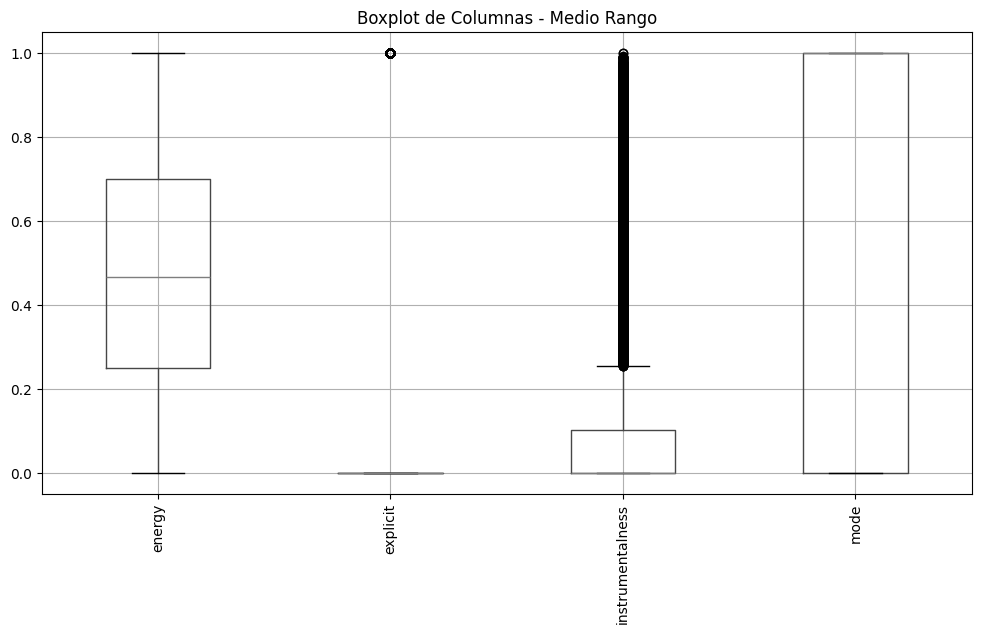

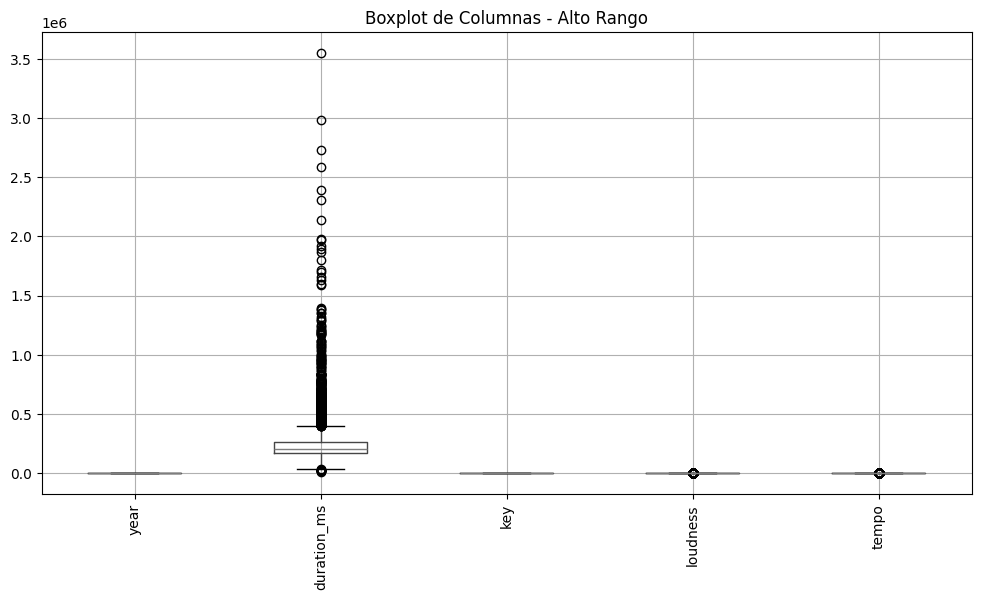

In [18]:
# 3. Calculo los outliers de las numéricas - dividiendolas por rangos porque sus valores son muy diferentes

ranges = df[numericas].max() - df[numericas].min()

# Agrupo las columnas por rangos similares usando percentiles
low_range = ranges[ranges < np.percentile(ranges, 33)].index
mid_range = ranges[(ranges >= np.percentile(ranges, 33)) & (ranges < np.percentile(ranges, 66))].index
high_range = ranges[ranges >= np.percentile(ranges, 66)].index

# Creo un diccionario de grupos
groups = {"Bajo Rango": low_range, "Medio Rango": mid_range, "Alto Rango": high_range}

# Creo gráficas para cada grupo
for group_name, cols in groups.items():
    if len(cols) > 0: 
        plt.figure(figsize=(12, 6))
        df[cols].boxplot(rot=90)
        plt.title(f"Boxplot de Columnas - {group_name}")
        plt.show()


Decido no tratar los outliers porque tienen sentido y aportan información importante a mi modelo

### 4. Correlaciones y Relaciones
    + Matriz de correlación (heatmap) ✅
    + Relaciones entre variables clave (scatter plots, pairplots) ✅ 
    + Relaciones entre variables y la variable objetivo (si la tienes definida) ✅

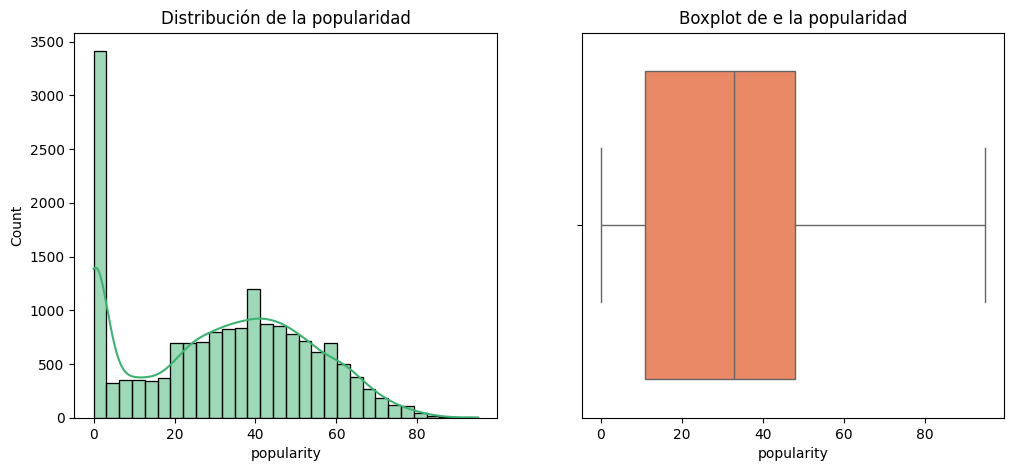

In [19]:
# Vemos la pinta de nuestra variable target
sns.set_palette(palette_color)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df["popularity"], bins=30, kde=True, color="mediumseagreen")
plt.title("Distribución de la popularidad")
plt.subplot(1, 2, 2)
sns.boxplot(x=df["popularity"], color="coral")
plt.title("Boxplot de e la popularidad")

plt.show()

In [20]:
# Correlación de las numéricas con el target
correlation_values = df[numericas].corrwith(df['popularity']).abs().sort_values(ascending=False)

# Muestro los resultados
print(correlation_values)

year                0.865075
acousticness        0.573953
energy              0.487435
loudness            0.456932
instrumentalness    0.284380
danceability        0.197776
explicit            0.186137
speechiness         0.180053
tempo               0.131336
liveness            0.080716
duration_ms         0.062447
mode                0.031623
key                 0.015406
valence             0.011189
dtype: float64


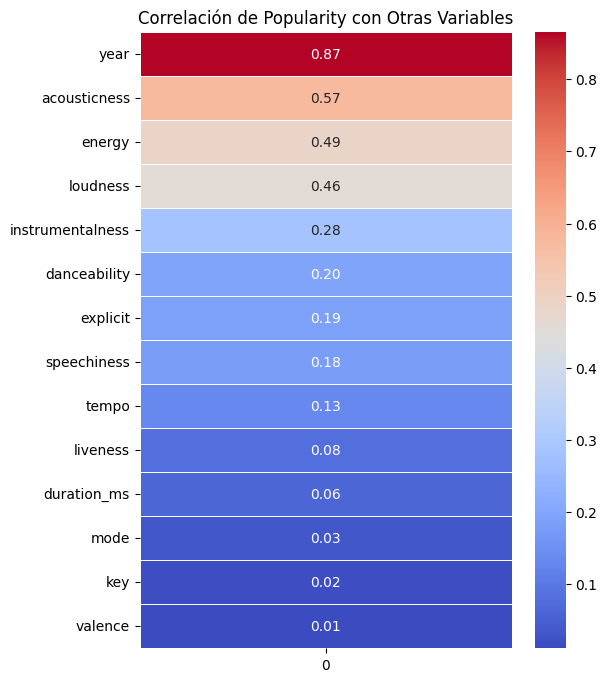

In [21]:
# Calculo la correlación absoluta con "popularity"
correlation_values = df[numericas].corrwith(df['popularity']).abs().sort_values(ascending=False)
corr_df = correlation_values.to_frame()

# Creo el heatmap
plt.figure(figsize=(6, 8))
sns.heatmap(corr_df, annot=True, cmap="coolwarm", linewidths=0.5, fmt=".2f", cbar=True)
plt.title("Correlación de Popularity con Otras Variables")
plt.show()

In [22]:
numericas = df.select_dtypes(include=["float64", "int64"]).columns

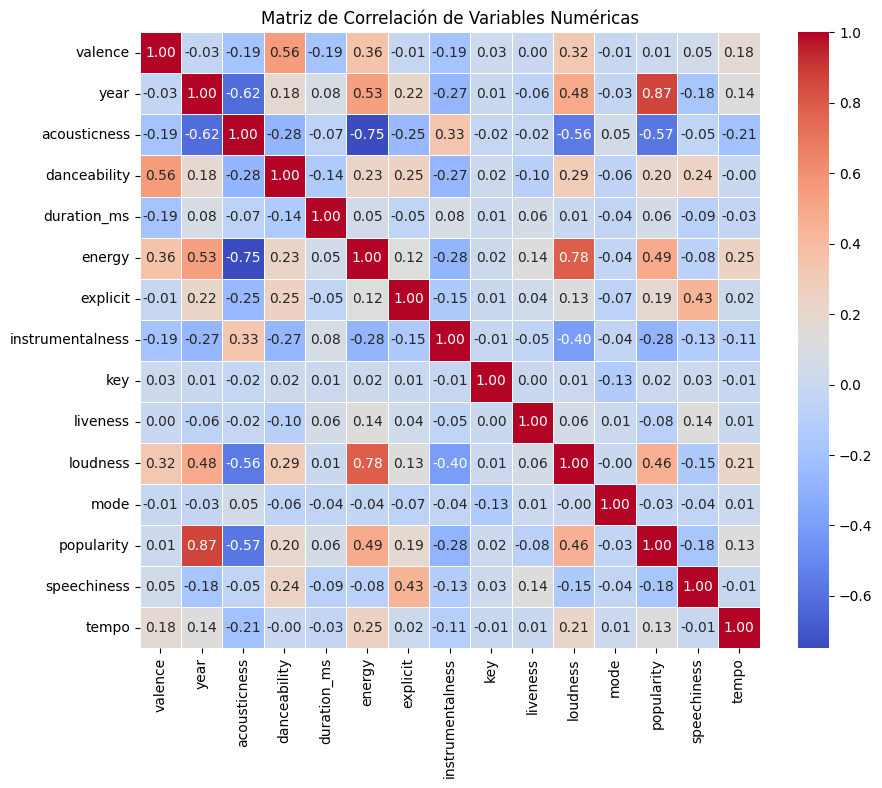

In [23]:
corr_matrix = df[numericas].corr()

# Crear el heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", linewidths=0.5, fmt=".2f", cbar=True)

plt.title("Matriz de Correlación de Variables Numéricas")
plt.show()

### 5. Análisis de Variables Categóricas
    + Análisis de artistas más populares ✅
    + Análisis de la variable explicit ✅
    + Análisis del modo y la tonalidad (key, mode) ✅


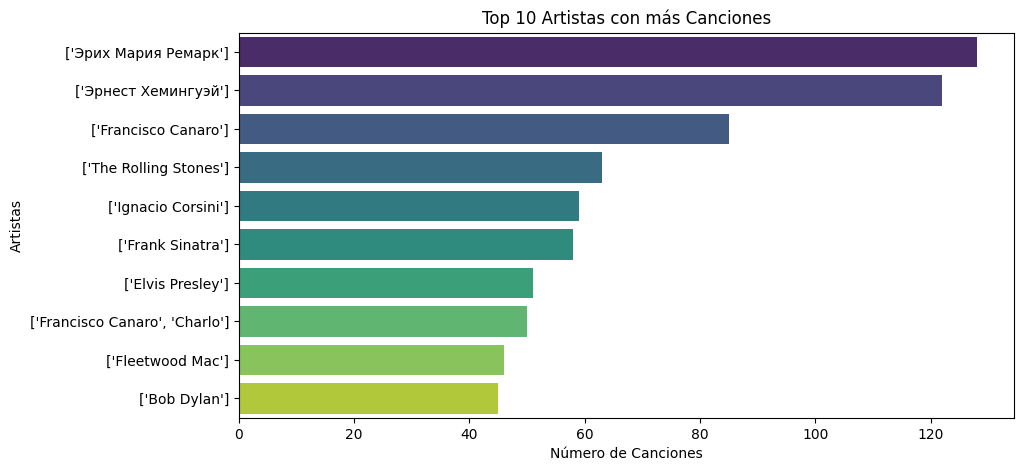

In [24]:
# Análisis de la variable artists
top_artistas = df['artists'].value_counts().head(10)
plt.figure(figsize=(10, 5))
sns.barplot(x=top_artistas.values, y=top_artistas.index, palette=palette_color)
plt.xlabel('Número de Canciones')
plt.ylabel('Artistas')
plt.title('Top 10 Artistas con más Canciones')
plt.show()

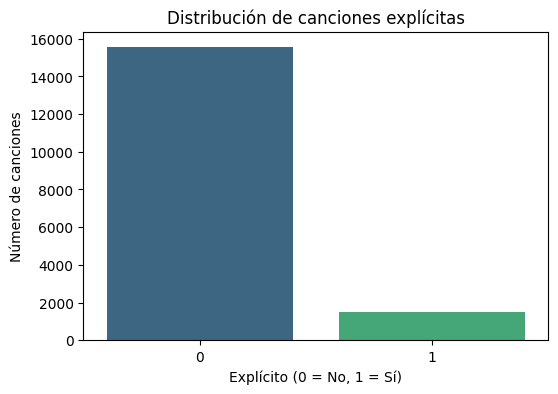

In [25]:
# Análisis de la variable explicit
plt.figure(figsize=(6, 4))
sns.countplot(x=df["explicit"], palette=palette_color)
plt.xlabel("Explícito (0 = No, 1 = Sí)")
plt.ylabel("Número de canciones")
plt.title("Distribución de canciones explícitas")
plt.show()

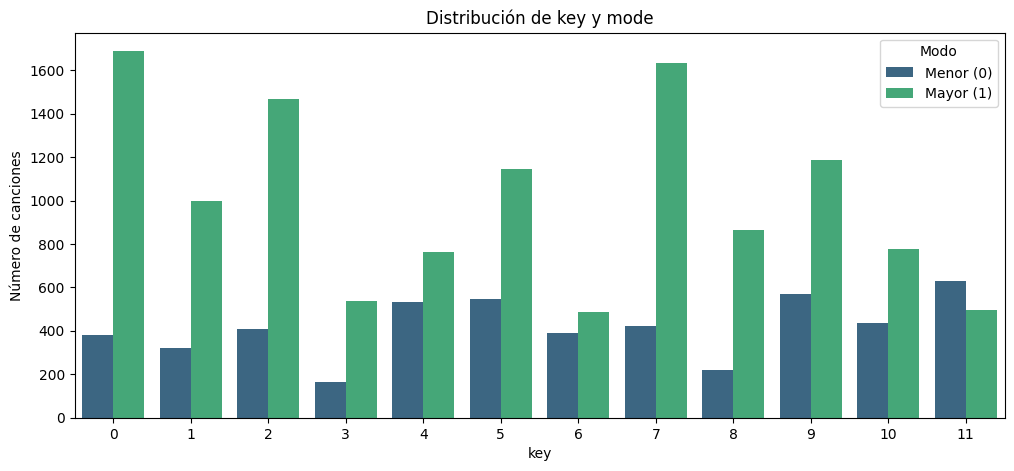

In [26]:
# Análisis de las variables key y mode
plt.figure(figsize=(12, 5))
sns.countplot(x=df["key"], hue=df["mode"], palette= palette_color)
plt.xlabel("key")
plt.ylabel("Número de canciones")
plt.title("Distribución de key y mode")
plt.legend(title="Modo", labels=["Menor (0)", "Mayor (1)"])
plt.show()

### 6. Tendencias Temporales
    + Evolución de la popularidad de las canciones a lo largo del tiempo ✅
    + Cambios en características como energy y danceability por año ✅


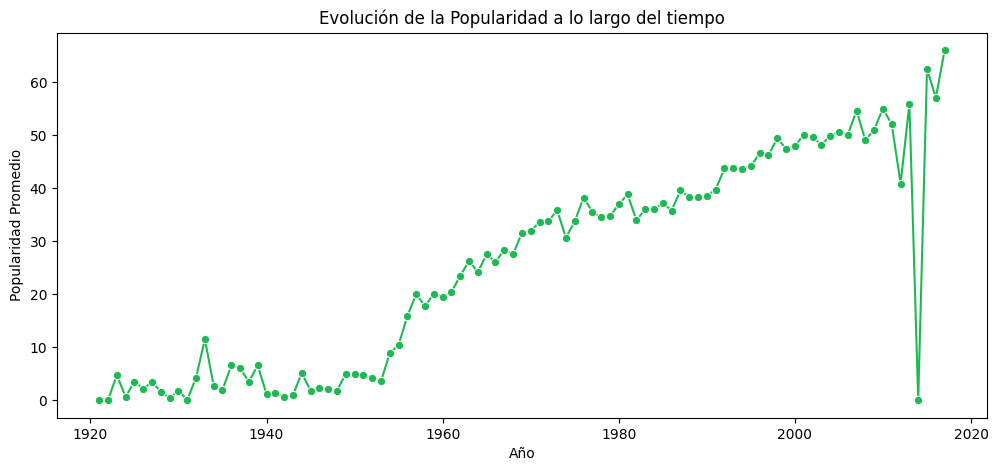

In [27]:
# Popularidad a lo largo del tiempo
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['year'] = df['release_date'].dt.year

df_yearly = df.groupby('year')['popularity'].mean().dropna()
plt.figure(figsize=(12, 5))
sns.lineplot(x=df_yearly.index, y=df_yearly.values, marker='o', color='#1DB954')
plt.xlabel('Año')
plt.ylabel('Popularidad Promedio')
plt.title('Evolución de la Popularidad a lo largo del tiempo')
plt.show()


<Figure size 1200x600 with 0 Axes>

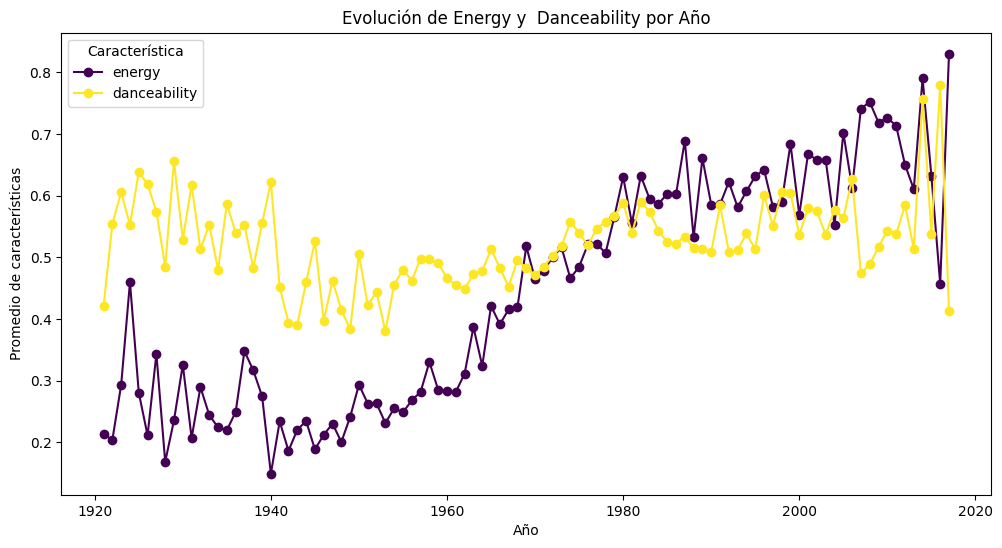

In [28]:
# Cambios en características como energy y danceability por año
plt.figure(figsize=(12, 6))
df.groupby("year")[["energy", "danceability"]].mean().plot(kind="line", figsize=(12, 6), marker="o", colormap=palette_color)
plt.xlabel("Año")
plt.ylabel("Promedio de características")
plt.title("Evolución de Energy y  Danceability por Año")
plt.legend(title="Característica")
plt.show()

## SEPARACIÓN Y TRANSFORMACIONES

In [29]:
# Elimino las columnas irrelevantes - finalmente me dan fallos en el modelo y no aportan información
df.drop(columns=["id", "release_date", "name", "artists"], inplace=True)

In [30]:
# Separo las features y de la target
X = df.drop(columns=["popularity"])
y = df["popularity"]

In [31]:
# Vuelvo a identificar los tipos de variables
features_numericas = X.select_dtypes(include=[np.number]).columns.tolist()
features_categoricas = ["mode", "key", "explicit"]

In [32]:
# Hago un preprocesamiento
num_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")), 
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=10))  
])
cat_transformer = OneHotEncoder(handle_unknown="ignore")

preprocessor = ColumnTransformer([
    ("num", num_transformer, features_numericas),
    ("cat", cat_transformer, features_categoricas)
])

In [33]:
# Hago el split entre train y test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## MODELADO Y EVALUACIÓN

In [34]:
# Modelos supervisados, elijo dos:
models = {
    "RandomForest": RandomForestRegressor(),
    "XGBoost": XGBRegressor(),
}

# Busco los mejores hiperparámetros (son rangos bajos para mejorar la rapidez de ejecucción)
param_grid = {
    "RandomForest": {"model__n_estimators": [50], "model__max_depth": [None, 10]},
    "XGBoost": {"model__n_estimators": [50], "model__learning_rate": [0.1]},
}
best_models = {}
for name, model in models.items():
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    grid_search = RandomizedSearchCV(
        pipeline, 
        param_distributions=param_grid[name],
        n_iter=3,  
        cv=2, 
        scoring="neg_mean_absolute_error", 
        random_state=42,
        n_jobs=-1  
    )
    grid_search.fit(X_train, y_train)
    best_models[name] = grid_search.best_estimator_
    y_pred = grid_search.predict(X_test)
    print(f"{name} MAE: {mean_absolute_error(y_test, y_pred):.4f}")


RandomForest MAE: 11.6171
XGBoost MAE: 11.6111


In [35]:
# Modelos no supervisados elijo solo uno por velocidad de ejecucción
X_scaled = preprocessor.fit_transform(X_train)
clusters = {
    "KMeans": KMeans(n_clusters=3, random_state=42),  
}

for name, model in clusters.items():
    labels = model.fit_predict(X_scaled)
    if len(set(labels)) > 1:
        score = silhouette_score(X_scaled, labels)
        print(f"{name} Silhouette Score: {score:.4f}")
    else:
        print(f"{name} could not form clusters effectively.")

KMeans Silhouette Score: 0.1413


In [36]:
import os

# Creao la carpeta src/models si no existe
os.makedirs('../models', exist_ok=True)

# Y guardo el modelo
import joblib
joblib.dump(model, '../models/modelo_final.pkl')


['../models/modelo_final.pkl']

## CONCLUSIONES

El trabajo ha sido arduo ya que los modelos no aceptaban de ninguna forma las variables categóricas, por lo que para hacer la predicción he obtado por eleminarlas ya que no aportaban demasiada información al modelo.

Podemos deducir que es mejor utilizar un modelo no supervisado como KMeans ya que arroja un error mucho más bajo que los modelos supervisados. No obstante, esto sirve como objeto de continuidad para seguir trabajando en este proyecto ya que es sospechoso que el error sea tan bajo. Puede que exista sobre ajuste en el modelo.

Por ello, dejamos abierto este proyecto para continuar trabajando y sacándole partido para una futura puesta en marcha en la industria musical.